In [125]:
# Для анализа данных и обработки
import pandas as pd
import numpy as np

# Для визуализации данных
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
# Pizza Sales Analysis
%matplotlib inline

# Pizza Sales Analysis

# Содержание

1. Описание проекта
2. Вопросы исследования и их цели
3. Описание данных
   - 3.1 Импорт и объединение таблиц
   - 3.2 Информация о данных
   - 3.3 Обзор данных
4. Исследовательские вопросы
    - 4.1 Общий объем заказов и продаж
    - 4.2 Популярность размеров
    - 4.3 Популярность пицц
    - 4.4 Популярность категорий
    - 4.5 Активность заказов по времени
    - 4.6 Динамика продаж
    - 4.7 Анализ выручки
    - 4.8 Вклад категорий в выручку
    - 4.9 Накопительная выручка
    - 4.10 Лидеры категорий
5. Итоговые выводы


# Описание проекта

Цель проекта — выявить закономерности в продажах сети Pizza Hut и сформулировать рекомендации по оптимизации ассортимента, повышению выручки и улучшению понимания поведения клиентов.

# Вопросы исследования и их цели

1. **Каков общий объем заказов и продаж?**  
  **Цель:** оценить масштаб бизнеса и определить базовые показатели продаж.

2. **Какие размеры пиццы наиболее популярны среди покупателей?**  
  **Цель:** определить потребительские предпочтения для оптимизации ассортимента и управления запасами.

3. **Какие виды пиццы заказывают чаще всего?**  
  **Цель:** выявить наиболее востребованные позиции меню.

4. **Какие категории пиццы наиболее популярны по объему продаж?**  
  **Цель:** определить категории, формирующие основной потребительский спрос.

5. **Как меняется активность заказов в течение дня?**  
  **Цель:** выявить часы пик для оптимизации работы персонала и логистики.

6. **Как распределяются заказы по дням недели?**  
  **Цель:** проанализировать дневную динамику продаж и средний объем заказов.


7. **Какие виды пиццы приносят наибольшую выручку?**  
  **Цель:** определить ключевые товары, формирующие основную часть дохода.

8. **Каков вклад каждой категории пиццы в общую выручку?**  
  **Цель:** определить финансовую значимость различных категорий меню.

9. **Как изменяется совокупная выручка во времени?**  
  **Цель:** проанализировать накопительную динамику дохода и выявить тенденции продаж.

10. **Какие виды пиццы являются наиболее доходными внутри каждой категории?**  
  **Цель:** определить лидирующие позиции по выручке в рамках каждой категории пиццы.

# Описание и подготовка данных

## Импорт и объединение таблиц

In [126]:
# таблица о деталях заказа
df_order_details = pd.read_csv('../pizza_hut_da/data/order_details.csv', encoding='windows-1251')
df_order_details.head(10)

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1
5,6,2,thai_ckn_l,1
6,7,3,ital_supr_m,1
7,8,3,prsc_argla_l,1
8,9,4,ital_supr_m,1
9,10,5,ital_supr_m,1


In [127]:
# таблица заказов
df_orders = pd.read_csv('../pizza_hut_da/data/orders.csv', encoding='windows-1251')
df_orders.head(10)

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30
5,6,2015-01-01,12:29:36
6,7,2015-01-01,12:50:37
7,8,2015-01-01,12:51:37
8,9,2015-01-01,12:52:01
9,10,2015-01-01,13:00:15


In [128]:
# таблица типов пиццы
df_pizza_types = pd.read_csv('../pizza_hut_da/data/pizza_types.csv',  encoding='windows-1251', )
df_pizza_types.head(10)

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."
5,thai_ckn,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha..."
6,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
7,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
8,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
9,ital_cpcllo,The Italian Capocollo Pizza,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,..."


In [129]:
# таблица пицц
df_pizzas = pd.read_csv('../pizza_hut_da/data/pizzas.csv', encoding='windows-1251')
df_pizzas.head(10)

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75
5,cali_ckn_l,cali_ckn,L,20.75
6,ckn_alfredo_s,ckn_alfredo,S,12.75
7,ckn_alfredo_m,ckn_alfredo,M,16.75
8,ckn_alfredo_l,ckn_alfredo,L,20.75
9,ckn_pesto_s,ckn_pesto,S,12.75


In [130]:
# Визуальный просмотр данных
df = (
    df_order_details
    .merge(df_orders, on='order_id', how='left')
    .merge(df_pizzas, on='pizza_id', how='left')
    .merge(df_pizza_types, on='pizza_type_id', how='left')
)
df.head(10)

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
5,6,2,thai_ckn_l,1,2015-01-01,11:57:40,thai_ckn,L,20.75,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha..."
6,7,3,ital_supr_m,1,2015-01-01,12:12:28,ital_supr,M,16.50,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
7,8,3,prsc_argla_l,1,2015-01-01,12:12:28,prsc_argla,L,20.75,The Prosciutto and Arugula Pizza,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella..."
8,9,4,ital_supr_m,1,2015-01-01,12:16:31,ital_supr,M,16.50,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
9,10,5,ital_supr_m,1,2015-01-01,12:21:30,ital_supr,M,16.50,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."


# Информация о данных

In [131]:
# Получение общей информации о наборе данных
print("\n Общая информаци о датасете: ")
print(df.info())


 Общая информаци о датасете: 
<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  str    
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  str    
 5   time              48620 non-null  str    
 6   pizza_type_id     48620 non-null  str    
 7   size              48620 non-null  str    
 8   price             48620 non-null  float64
 9   name              48620 non-null  str    
 10  category          48620 non-null  str    
 11  ingredients       48620 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 4.5 MB
None


In [132]:
# информация о количестве записей и столбцов
print("\nКоличество строк и столбцов в датафрейме:")
rows, cols = df.shape
print(f"Строк: {rows}, Столбцов: {cols}")


Количество строк и столбцов в датафрейме:
Строк: 48620, Столбцов: 12


In [133]:
# Наличие пропусков в датасете
print("\nПропуски данных в датасете")
print(df.isna().sum())


Пропуски данных в датасете
order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64


In [134]:
# Наличие дубликатов в датасете
print(f"Наличие дубликатов в данных датасета: {df.duplicated().sum()}")

Наличие дубликатов в данных датасета: 0


In [135]:
# Получение статистики по числовым столбцам
print("\nОписательная статистика для числовых данных:")
print(df['quantity'].describe())
print()
print(df['price'].describe())
print()

# Добавление revenue в dataframe
df['revenue'] = df['quantity'] * df['price']
print(df['revenue'].describe())


Описательная статистика для числовых данных:
count    48620.000000
mean         1.019622
std          0.143077
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: quantity, dtype: float64

count    48620.000000
mean        16.494132
std          3.621789
min          9.750000
25%         12.750000
50%         16.500000
75%         20.250000
max         35.950000
Name: price, dtype: float64

count    48620.000000
mean        16.821474
std          4.437398
min          9.750000
25%         12.750000
50%         16.500000
75%         20.500000
max         83.000000
Name: revenue, dtype: float64


In [136]:
total_memory = df.memory_usage(deep=True).sum()
print(f'Общий объем памяти: {total_memory / 1024:.2f} KB')

Общий объем памяти: 27090.48 KB


In [137]:
# Обзор данных

## Общая информация

- **Тип:** `pandas.DataFrame`
- **Записей:** 48620
- **Столбцов:** 12

## Столбцы

- **`order_details_id`** - Уникальный идентификатор позиции в заказе. Каждая строка соответствует одельной позиции заказа.
- **`order_id`** - Уникальный идентификатор заказа. Используется для связи с информацией о заказе.
- **`pizza_id`** - Ссылка на конкретную пиццу.
- **`quantity`** - Количество пицц данного вида в заказе.
- **`date`** - Дата заказа.
- **`time`** - Время заказа.
- **`pizza_type_id `** - Уникальный идентификатор рецепта пиццы.
- **`size`** - Размер пиццы ('S', 'M', 'L' и т.д.).
- **`price`** - Стоимость одной пиццы
- **`name`** - Наименование пиццы.
- **`category`** - Категория пиццы (Classc, Supreme, Chicken и т.д.).
- **`ingredients`** - Состав ингредиентов, входящих в рецепт пиццы.

## Память

- **Размер:** 26710.63+ KB

## Описательные статистики

- Среднее количество пицц в одной позиции составляет 1.02. Медианное значение равно 1, а 75% всех наблюдений также не превышает 1. Это свидетельствует о том, что в большинстве случаев покупатели заказывают одну единицу конкретного вида пиццы, тогда как заказы нескольких одинаковых пицц встречаются значительно реже.

- Средняя цена пиццы составляет 16.49 долларов, медианная - 16.50 долларов. Близость среднего и медианного значений свидетельствует об относительно сбалансированном распределении цен без выраженного влияния дорогих или дешёвых позиций. Стоимость пиццы варьируется от 9.75 да 35.95 долларов.

- Средняя выручка с одной позиции заказа составляет 16.82 долларов, а медианная - 16.50 долларов. Близость среднего и медианного значений указывает на отсутствие сильной асимметрии распределения. Половина наблюдений имеет выручку не более 16.50 долларов, а 75% - не более 20.50 долларов. Стоимость отдельного заказа варьируется от 9.75 долларов до 83.00. Высокое максимальное значение может быть связано с заказом нескольких единиц дорогой пиццы в рамках одно позиции заказа.


## Пропущенные значения

Отсутствуют.

# Исследовательские вопросы

## **1. Каков общий объем заказов и продаж?**

Подсчитываем количество всех заказов по следующим критериям: количество заказов, количество прооданных пицц, общая выручка, средний чек, среднее количество пицц в заказе.

In [138]:
# количество заказов
total_orders = df['order_id'].nunique()

# продано пицц
total_pizzas = df['quantity'].sum()

# общая выручка
total_revenue = df['revenue'].sum()

# средний чек
avg_order_value = (
    df.groupby('order_id')['revenue']
      .sum()
      .mean()
)

# среднее количество пицц в заказе
avg_pizzas_per_order = (
    df.groupby('order_id')['quantity']
        .sum()
        .mean()
)

# вывод всей информации
print(f"Количество заказов: {total_orders:,}")
print(f"Продано пицц: {total_pizzas:,}")
print(f"Общая выручка: {total_revenue:,.2f} $")
print(f'Средний чек: {avg_order_value:.2f} $')
print(f'Среднее количество пицц в заказе: {avg_pizzas_per_order:.2f}')

Количество заказов: 21,350
Продано пицц: 49,574
Общая выручка: 817,860.05 $
Средний чек: 38.31 $
Среднее количество пицц в заказе: 2.32


### Выводы:
- За анализируемый период было оформлено 21 350 заказов, в рамках которых продано 49 574 пиццы. Общая выручка составила 817 860 долларов.
- Средний чек одноого заказа равен 38.31 доллара, а среднее количество пицц в заказе - 2.32. Это указывает на то, что покупатели часто приобретают несколько пицц за один заказ, что может быть связано с семейным или групповым потреблением.
- Средний чек более чем в два раза превышает чреднюю стоимость одной пиццы, что подтверждает начиличие многопозиционных заказов.

## **2. Какие размеры пиццы наиболее популярны среди покупателей?**

### Анализ продаж по размерам пиццы

Для определения наиболее популярных размеров рассчитаем общее количество проданных пицц каждого размера.

In [139]:
# Пишем запрос, который рассчитает общее количество проданных пицц каждого размера
popular_sizes = (
    df.groupby('size')['quantity']
        .sum()
        .sort_values(ascending=False)
)

# Вывод результатов запроса
popular_sizes

size
L      18956
M      15635
S      14403
XL       552
XXL       28
Name: quantity, dtype: int64

### Анализ результатов

Наиболее популярным размером является **L**, за ним следуют **M** и **S**. Размеры **XL** и **XXL** встречаются значительно реже.
Для проверки влияния цены рассчитаем среднюю стоимость пиццы каждого размера.

In [140]:
# Пишем запрос, который рассчитает среднюю стоимость пиццы каждого размера
avg_price_by_size = (
    df.groupby('size')['price']
        .mean()
        .sort_values()
)

# Вывод результатов запроса
print("Размеры пиццы")
avg_price_by_size

Размеры пиццы


size
S      12.364328
M      15.951219
L      19.802553
XL     25.500000
XXL    35.950000
Name: price, dtype: float64

### Анализ результатов

Размер XXL существенно дороже остальных вариантов. Однако разница между размерами L и XL составляет всего около 6 долларов, что не объясняет столь сильное падение спроса.

### **Гипотеза**

Возникает гипотеза: покупатели предпочитают заказывать несколько разных пицц вместо одной очень большой.

### Проверка гипотезы

Посчитаем количество различных видов пиццы в одном заказе.

In [141]:
# проверяем сколько в среднем покупают пицц за заказ
pizzas_per_order = (
    df.groupby('order_id')['pizza_id']
        .nunique()
)

# Вывод результатов запроса
pizzas_per_order.describe()

count    21350.000000
mean         2.277283
std          1.705720
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         21.000000
Name: pizza_id, dtype: float64

 Рассчитаем долю заказов, содержащих более одного вида пиццы.

In [142]:
# какой процент пицц в заказе содержит две пиццы
orders_unique_pizzas = (
    df.groupby('order_id')['pizza_id']
        .nunique()
)

orders_unique_pizzas_per = (orders_unique_pizzas > 1).mean() * 100

print(f'Доля заказов, содержащих более одного вида пиццы: {orders_unique_pizzas_per:.2f} %.')

Доля заказов, содержащих более одного вида пиццы: 61.59 %.


### Анализ результатов

В среднем заказ содержит 2.28 различных пиццы, а более 61% заказов включают несколько видов пиццы. Это подтверждает предположение о том, что покупатели предпочитают разнообразие вкусов в рамках одного заказа.

### Дополнительная проверка

Проверим ассортименть пицц для каждого размера.

In [143]:
# ассортимент пицц
df.groupby('size')['name'].nunique()

size
L      30
M      29
S      30
XL      1
XXL     1
Name: name, dtype: int64

### Анализ результатов

Размеры XL и XXL представлены всего одним видом пиццы, тогда как размеры S, M и L доступны практически для всего ассортимента.

### **Гипотеза** 

Пиццы размера XL и XXL приносят минимальную прибыль для бизнеса

### Проверка гипотезы

In [144]:
# Поситаем суммы прибыли по каждому размеру пиццы
revenue_by_size = (
    df.groupby('size')['revenue']
        .sum()
        .sort_values(ascending=False)
)

# Выводим результат
revenue_by_size

size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: revenue, dtype: float64

In [145]:
# Посчитаем долю по прибыли по каждому размеру пиццы
share_by_size = (
    revenue_by_size /
    revenue_by_size.sum() * 100
)

# Выводим результат
share_by_size

size
L      45.890333
M      30.492044
S      21.773468
XL      1.721077
XXL     0.123077
Name: revenue, dtype: float64

### Анализ результатов

Пиццы размера XL и XXL составляют чуть меньше 2 % доли всех продаж, что говорит о низком интересе потребителей к данным размерам.

### **Визуализация**

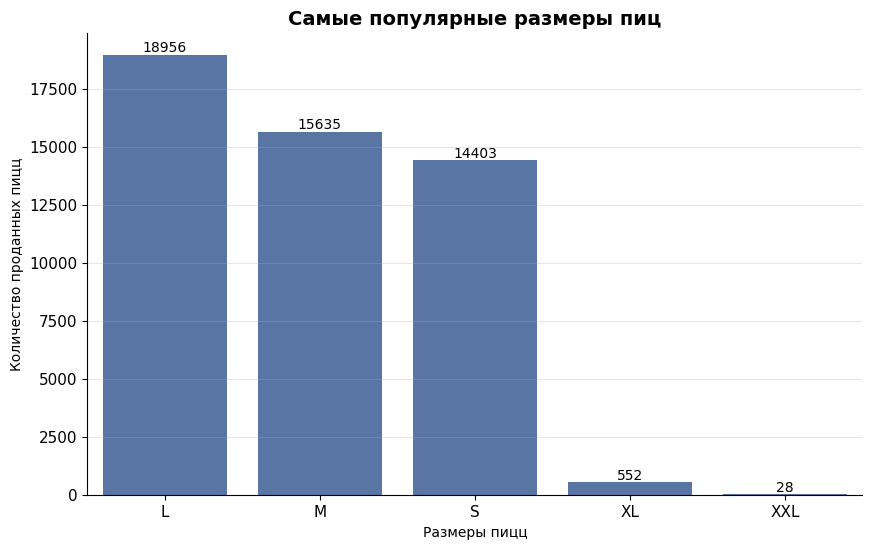

Наиболее популярный размер пиццы: L.
С количеством 18,956 проданных пицц.
Таблица с количеством продаж и проданной доли по каждому размеру пиццы:


Размер,Продажи,Доля (%)
L,"18,956",38.2
M,"15,635",31.5
S,"14,403",29.1
XL,552,1.1
XXL,28,0.1


In [146]:
# Создаем фигуру и ось
fig, ax = plt.subplots(figsize=(10, 6))

# Строим график
sns.barplot(data=popular_sizes, ax=ax, color="#4C72B0")

# Настраиваем заголовок и подписи
ax.set_ylabel('Количество проданных пицц')
ax.set_xlabel('Размеры пицц')
ax.set_title(
    'Самые популярные размеры пиц',
    fontsize=14,
    weight='bold')

# Добавляем метки над барами
ax.bar_label(ax.containers[0])

# Отображаем сетку по Y
ax.grid(axis='y', alpha=0.3)

# Убираем верхнюю и правую рамку
sns.despine()

# Настраиваем шрифт подписей
ax.tick_params(labelsize=11)

# Отображаем график
plt.show()


# Сортируем по количеству объкетов по убыванию
popular_sizes_sorted = popular_sizes.sort_values(ascending=False)

# Определяем тип с максимальным количеством
top_type_size = popular_sizes.index[0]
top_coun_size = popular_sizes.iloc[0]

# Выводим результаты
print("====================================================")
print(f"Наиболее популярный размер пиццы: {top_type_size}.\nС количеством {top_coun_size:,} проданных пицц.")
print("====================================================")

# Также выводим полный список с их количеством
print("Таблица с количеством продаж и проданной доли по каждому размеру пиццы:")
result = popular_sizes.reset_index()
result.columns = ['Размер', 'Продажи']

result['Доля (%)'] = (
    result['Продажи'] /
    result['Продажи'].sum() * 100
)

result.style \
    .hide(axis='index') \
    .format({
        'Продажи': '{:,.0f}',
        'Доля (%)': '{:.1f}'
    })

### Вывод
Размер L является наиболее популярным среди покупателей. Низкие продажи размеров XL и XXL объясняются не только более высокой стоимостью, но и крайне ограниченным ассортиментом. Кроме того, большинство клиентов предпочитают заказывать несколько различных видов пиццы в рамках одного заказа, что снижает потребность в покупке одной большой пиццы.

### Интерес для бизнеса

- Покупатели чаще предпочитают разнообразие вкусов, чем покупку одной большой пиццы. При планировании ассортимента компании следует учитывать, что расширение линейки размеров XL и XXL может не привести к существенному росту спроса без дополнительного анализа их вклада в выручку.
- Полученные показатели могут использоваться как базовые метрики для оценки эффективности бизнеса и сравнения с будущими периодами. Средний чек и среднее количество пицц в заказе также могут служить ориентирами при разработке маркетинговых акций и программ повышения продаж.
- Лидеры продаж формируют значительную часть спроса и требуют постоянного контроля доступности ингредиентов. Кроме того, данные позиции могут использоваться в рекламных кампаниях и специальных предложениях.

## **3. Какие виды пиццы заказывают чаще всего?**

In [147]:
# Пишем запрос, который покажет какие виды пиццы заказывают чаще всего
popular_categories = (
    df.groupby('name')['quantity']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)

# Делаеи копию таблицы для формирования результата
result = popular_categories.copy()

# Добавляем в результат две колонки
result.columns = ['Категория', 'Продажи']

# Рассчитываем в результате доли продаж для каждого вида пиццы
result['Доля (%)'] = (
    result['Продажи'] / result['Продажи'].sum() * 100
).round(1)

# Выводим 10 самых продаваемых видов пиццы
result.head(10)

,Категория,Продажи,Доля (%)
0,The Classic Deluxe Pizza,2453,4.9
1,The Barbecue Chicken Pizza,2432,4.9
2,The Hawaiian Pizza,2422,4.9
3,The Pepperoni Pizza,2418,4.9
4,The Thai Chicken Pizza,2371,4.8
5,The California Chicken Pizza,2370,4.8
6,The Sicilian Pizza,1938,3.9
7,The Spicy Italian Pizza,1924,3.9
8,The Southwest Chicken Pizza,1917,3.9
9,The Big Meat Pizza,1914,3.9


### Анализ результатов

- Наиболее популярными являются The Classic Deluxe Pizza, The Barbecue Chicken Pizza, The Hawaiian Pizza и The Pepperoni Pizza. Каждая из них формирует около 5% всех продаж.

- Наименее популярной является The Brie Carre Pizza, доля которой составляет лишь 1% от общего объема продаж.

- Разница между лидером и аутсайдером составляет почти пятикратное значение, что свидетельствует о заметных различиях в потребительских предпочтениях.

### **Гипотеза**

Цена влияет на популярность

In [148]:
# Пишем запрос, который выводит цену для каждой виды пиццы
pizza_price = (
    df.groupby('name')['price']
        .mean()
        .sort_values(ascending=False)
)

# Выводим стоимость для каждой пиццы
pizza_price

name
The Brie Carre Pizza                          23.650000
The Greek Pizza                               20.035633
The Five Cheese Pizza                         18.500000
The Thai Chicken Pizza                        18.286069
The Spicy Italian Pizza                       18.104663
The Southwest Chicken Pizza                   18.080504
The Mexicana Pizza                            18.024038
The Italian Supreme Pizza                     17.769740
The Pepper Salami Pizza                       17.637834
The Barbecue Chicken Pizza                    17.572934
The California Chicken Pizza                  17.448523
The Italian Capocollo Pizza                   17.426803
The Chicken Pesto Pizza                       17.153746
The Chicken Alfredo Pizza                     17.121429
The Soppressata Pizza                         17.077064
The Calabrese Pizza                           17.005124
The Four Cheese Pizza                         16.951946
The Prosciutto and Arugula Pizza           

In [149]:
# Выводим виды пиццы, котоыре заказывают реже всего
popular_categories.head()
popular_categories.tail()

,name,quantity
27,The Soppressata Pizza,961
28,The Spinach Supreme Pizza,950
29,The Calabrese Pizza,937
30,The Mediterranean Pizza,934
31,The Brie Carre Pizza,490


### Анализ результатов
Самая непопулярная пицца (The Brie Carre Pizza) одновременно является самой дорогой в ассортименте, что может свидетельствовать о влиянии цены на спрос. Однако среди лидеров продаж также присутствуют относительно дорогие позиции, поэтому цена не является единственным фактором, определяющим популярность продукта.

In [150]:
# посчитаем корреляцию между ценой и продажами
pizza_stats = (
    df.groupby('name')
        .agg(
            sales=('quantity', 'sum'),
            avg_price=('price', 'mean')
        )
)

# Выводим корелляцию
pizza_stats.corr(numeric_only=True)

,sales,avg_price
sales,1.000000,-0.306351
avg_price,-0.306351,1.000000


### Анализ результатов

Цена влияет на продажи, но не определяет их полностью.

### **Визуализация**

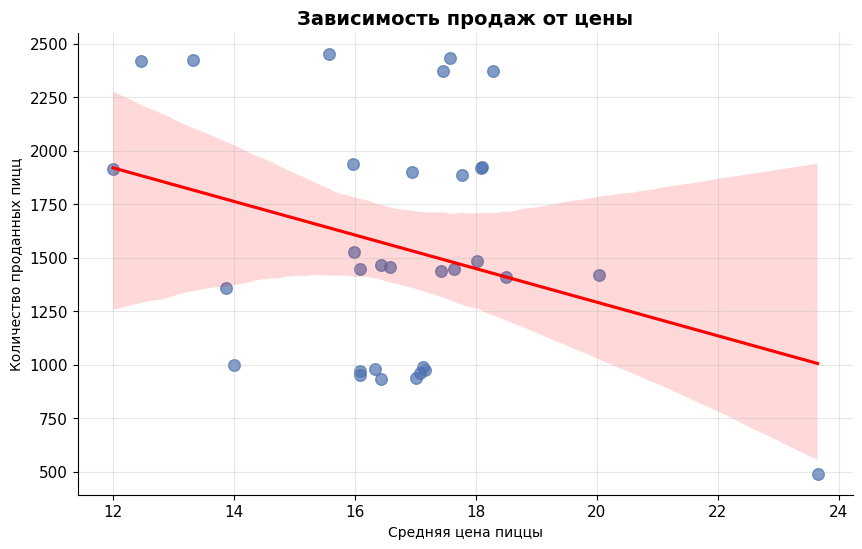

Результаты анализа:
Анализ зависимости количества продаж от средней цены
Коэффициент корреляции между средней ценой и продажами: -0.31


In [151]:
# Создание scatter
fig, ax = plt.subplots(figsize=(10, 6))

# Диаграмма для оценки связи между средней ценой и продажами
ax.scatter(
    pizza_stats['avg_price'],
    pizza_stats['sales'],
    s=70,
    alpha=0.7,
    color="#4C72B0"
)

# Добавляем линия тренда
sns.regplot(
    data=pizza_stats,
    x='avg_price',
    y='sales',
    scatter=False,
    ax=ax,
    color='red'
)

# Настройка осей и названия
ax.set_xlabel('Средняя цена пиццы')
ax.set_ylabel('Количество проданных пицц')
ax.set_title(
    'Зависимость продаж от цены',
    fontsize=14,
    weight="bold")

# Отображаем сетку по Y
ax.grid(alpha=0.3)

# Убираем верхнюю и правую рамку
sns.despine()

# Настраиваем шрифт подписей
ax.tick_params(labelsize=11)

# Отображение графика
plt.show()

#Выводим результаты
print("Результаты анализа:")
print("===========================================================")
print("Анализ зависимости количества продаж от средней цены")
print("===========================================================")
corr = pizza_stats['sales'].corr(pizza_stats['avg_price'])
print(f"Коэффициент корреляции между средней ценой и продажами: {corr:.2f}")

In [152]:
# Выбираем 10 самых популярных видов пиццы
top_ten_pizzas = popular_categories.head(10)

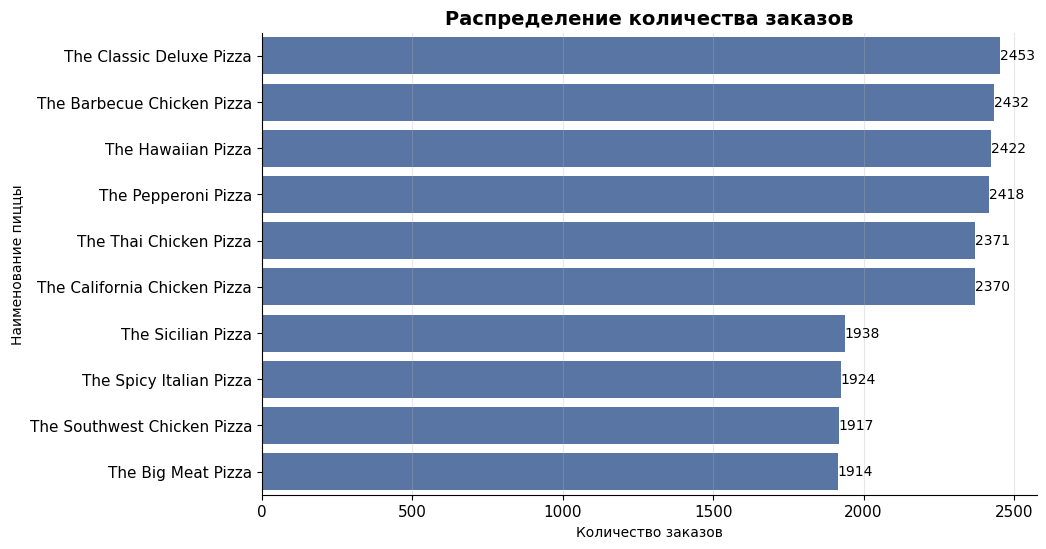

Результаты анализа:
Виды пиццы которые заказывают чаще всего:
1. The Classic Deluxe Pizza — 2453 заказов
2. The Barbecue Chicken Pizza — 2432 заказов
3. The Hawaiian Pizza — 2422 заказов
4. The Pepperoni Pizza — 2418 заказов
5. The Thai Chicken Pizza — 2371 заказов
6. The California Chicken Pizza — 2370 заказов
7. The Sicilian Pizza — 1938 заказов
8. The Spicy Italian Pizza — 1924 заказов
9. The Southwest Chicken Pizza — 1917 заказов
10. The Big Meat Pizza — 1914 заказов


In [153]:
# Создание столбчатой диаграммы
fig, ax = plt.subplots(figsize=(10, 6))

# Построение столбчатой диаграммы
sns.barplot(data=top_ten_pizzas, x='quantity', y='name', ax=ax, color="#4C72B0")

# Настройка осей и названий
ax.set_xlabel('Количество заказов')
ax.set_ylabel('Наименование пиццы')
ax.set_title(
    'Распределение количества заказов',
    fontsize = 14,
    weight="bold")

# Добавляем метки над барами
ax.bar_label(ax.containers[0], fmt='%.0f')

# Отображаем сетку по Y
ax.grid(axis='x', alpha=0.3)

# Убираем верхнюю и правую рамку
sns.despine()

# Настраиваем шрифт подписей
ax.tick_params(labelsize=11)

# Отображение диаграммы
plt.show()

# Выводим результаты
print("Результаты анализа:")
print("====================================================")
print("Виды пиццы которые заказывают чаще всего:")
print("\n".join(f"{i+1}. {row['name']} — {row['quantity']} заказов" for i, row in top_ten_pizzas.iterrows()))
print("====================================================")

### Выводы

- Анализ продаж показал, что наибольшим спросом пользуются классические и хорошо знакомые покупателями виды пиццы.
- При этом между средней ценой и объёмом продаж наблядается умеренная отрицательная связь (r = - 0.31): более дорогие позиции в среднем продаются хуже.
- Однако цена не является единственным фактором спроса, поскольку некоторые относительно дорогие пиццы также входят в число лидеров продаж.

### Интерес для бизнеса

- Рекомендуется поддерживать постоянное наличие популярных классических позиций.
- Использовать их в акциях и рекламных кампаниях как "локомотивы продаж".
- Пересмотреть стратегию для дорогих и нишевых пицц (например, The Brie Carre Pizza): протестировать снижение цены, изменение рецептуры или продвижение.

## **4. Какие категории пиццы наиболее популярны по объему продаж?**

In [154]:
# Рассчитываем суммы популярных категорий пиццы
popular_category_per_orders = (
    df.groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Добавляем названия к колонкам
result = popular_category_per_orders.copy()
result.columns = ['Категория', 'Продажи']

# Рассчитываем долю и продажи по категориям
result['Доля (%)'] = (
    result['Продажи'] /
    result['Продажи'].sum() * 100
).round(1)

# Выводим результат
result

,Категория,Продажи,Доля (%)
0,Classic,14888,30.0
1,Supreme,11987,24.2
2,Veggie,11649,23.5
3,Chicken,11050,22.3


### Анализ результатов

- Категория Classic является наиболее популярной и формирует около 30% всех продаж.
- Остальные категории имеют сопоставимый уровень спроса: их доля находится в диапазоне от 22% до 24%.
- Это говорит о достаточно равномерном распределении предпочтений покупателей между различными категориями пиццы.

### **Визуализация**

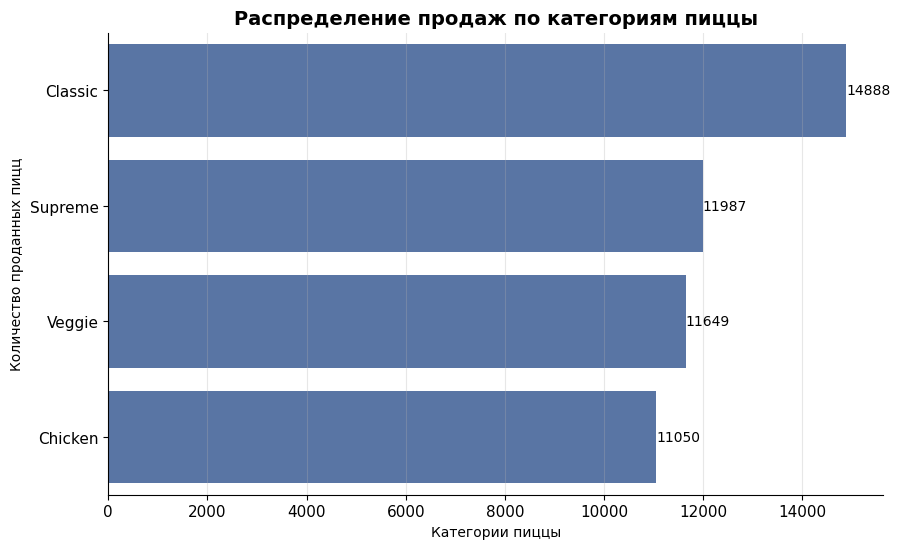

Результаты анализа:
Виды пиццы которые заказывают чаще всего:
1. Classic — 14888 заказов
2. Supreme — 11987 заказов
3. Veggie — 11649 заказов
4. Chicken — 11050 заказов


In [155]:
# Создаем фигуру и ось
fig, ax = plt.subplots(figsize=(10, 6))

# Строим график
sns.barplot(data=popular_category_per_orders, x='quantity', y='category', ax=ax, color="#4C72B0")

# Настраиваем заголовок и подписи
ax.set_xlabel('Категории пиццы')
ax.set_ylabel('Количество проданных пицц')
ax.set_title(
    'Распределение продаж по категориям пиццы',
    fontsize = 14,
    weight="bold"
)

# Добавляем метки над барами
ax.bar_label(ax.containers[0], fmt='%.0f')

# Отображаем сетку по Y
ax.grid(axis='x', alpha=0.3)

# Убираем верхнюю и правую рамку
sns.despine()

# Настраиваем шрифт подписей
ax.tick_params(labelsize=11)

# Отображение диаграммы
plt.show()

# Выводим результаты
print("Результаты анализа:")
print("====================================================")
print("Виды пиццы которые заказывают чаще всего:")
print("\n".join(f"{i+1}. {row['category']} — {row['quantity']} заказов" for i, row in popular_category_per_orders.iterrows()))
print("====================================================")

### Выводы

- Категория Classic является наиболее популярной среди покупателей и формирует около 30% всех продаж.
- Остальные категории имеют сопоставимый уровень спроса: их доля находится в диапазоне от 22% до 24%.
- Это свидетельствует о достаточно равномерном распределении потребительских предпочтений между различными категориями пиццы.

### Интерес для бизнеса

- Результаты показывают, что покупатели проявляют интерес ко всем категориям пиццы. Следовательно, для поддержания стабильного спроса компании важно сохранять разнообразие ассортимента и не концентрироваться исключительно на одной категории продукции.

## **5. Как меняется активность заказов в течение дня?**

In [156]:
# Извлекаем hour из time и добавляем в наш dataframe
df['hour'] = df['time'].str[:2].astype(int)

In [157]:
# Считаем заказы по часам
orders_by_hour = (
    df.groupby('hour')['order_id']
        .nunique()
)

# Выводим результаты заказов по часам
orders_by_hour

hour
9        1
10       8
11    1231
12    2520
13    2455
14    1472
15    1468
16    1920
17    2336
18    2399
19    2009
20    1642
21    1198
22     663
23      28
Name: order_id, dtype: int64

### Анализ результатов

- Активность клиентов в течение дня имеет два выраженных пика.
  
- Первый пик приходится на период с 12:00 до 13:00, когда количество заказов достигает максимальных значений. Вероятно, это связано с обеденным временем.

  
- Второй пик наблюдается с 17:00 до 19:00. Данный период может быть связан с окончанием рабочего дня и временем ужина.

  
- Минимальная активность наблюдается утром до 11:00 и поздно вечером после 22:00.

### **Визуализация**

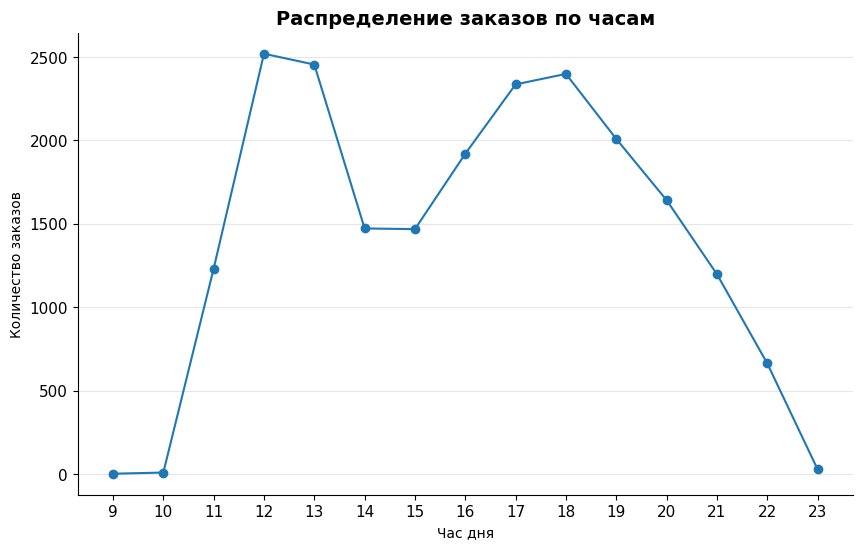

Результаты анализа:
Изменение активности заказов в течение дня:
9:00 — 1 заказов
10:00 — 8 заказов
11:00 — 1231 заказов
12:00 — 2520 заказов
13:00 — 2455 заказов
14:00 — 1472 заказов
15:00 — 1468 заказов
16:00 — 1920 заказов
17:00 — 2336 заказов
18:00 — 2399 заказов
19:00 — 2009 заказов
20:00 — 1642 заказов
21:00 — 1198 заказов
22:00 — 663 заказов
23:00 — 28 заказов


In [158]:
# Создаем фигуру и ось
fig, ax = plt.subplots(figsize=(10, 6))

# Строим график
ax.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    marker='o'
)

# Показываем только основное рабочее время (В Индии рабочий день начинается с 10-11 дня и заканчивается в 23 ночи)
ax.set_xticks(range(9, 24))

# Настраиваем заголовок и подписи
ax.set_title(
    'Распределение заказов по часам',
    fontsize=14,
    weight='bold')

ax.set_xlabel('Час дня')
ax.set_ylabel('Количество заказов')

# Настраиваем прозрачность сетки
ax.grid(axis='y', alpha=0.3)

# Убираем верхнюю и правую рамку
sns.despine()

# Настраиваем шрифт подписей
ax.tick_params(labelsize=11)

# Отображение диаграммы
plt.show()

# Выводим результаты
print("Результаты анализа:")
print("====================================================")
print("Изменение активности заказов в течение дня:")
print("\n".join(
    f"{hour}:00 — {orders} заказов"
    for hour, orders in orders_by_hour.items()))
print("====================================================")

### Выводы

- В течение дня наблюдаются два выраженных пика активности заказов.

- Первый приходится на промежуток с 12:00 до 13:00, второй на 17:00.

- После 19 часов количесво заказов начинает постепенно снижаться, а после 21:00 спад становится особенно заметным.

- Минимальная активность наблюдается в утренние часы до 11:00 и поздно вечером после 22:00.

### Интерес для бизнеса

- Результаты позваляют определить часы максимальной нагрузки и использовать их при планировании смен сотрудников кухни, курьеров и операторов. Это помогает сократить время ожидания клиентов в час пик.

- Поскольку основной поток заказов приходится на обеденное и вечернее время, в эти периоды можно запускать специальные предложения для увелечения среднего чка. В часы низкой активности, наоборот, можно использовать скидки и акции, стимулирующие дополнительный спрос

## **6. Как распределяются заказы по дням недели?**

In [159]:
# Считаем количество заказов для каждой календарной даты
orders_per_day = (
    df.groupby('date')['order_id']
        .nunique()
        .reset_index(name='orders')
)

# Преобразуем date в тип datetime
orders_per_day['date'] = pd.to_datetime(orders_per_day['date'])

# Выводим результат
orders_per_day.head(10)

,date,orders
0,2015-01-01,69
1,2015-01-02,67
2,2015-01-03,66
3,2015-01-04,52
4,2015-01-05,54
5,2015-01-06,64
6,2015-01-07,58
7,2015-01-08,72
8,2015-01-09,62
9,2015-01-10,65


In [160]:
# Сохраняем дни недели на русском
days = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

# Выделяем  дни недели и заказы в эти дни
orders_per_day['day_of_week'] = (
    orders_per_day['date']
        .dt.dayofweek
        .map(days))
        
# Выводим результат
orders_per_day.head(10)

,date,orders,day_of_week
0,2015-01-01,69,Четверг
1,2015-01-02,67,Пятница
2,2015-01-03,66,Суббота
3,2015-01-04,52,Воскресенье
4,2015-01-05,54,Понедельник
5,2015-01-06,64,Вторник
6,2015-01-07,58,Среда
7,2015-01-08,72,Четверг
8,2015-01-09,62,Пятница
9,2015-01-10,65,Суббота


In [161]:
# Порядок дней недели
order = [
    'Понедельник',
    'Вторник',
    'Среда',
    'Четверг',
    'Пятница',
    'Суббота',
    'Воскресенье'
]

# Считыем среднее количество заказов по дням в неделю
orders_by_weekday = (
    orders_per_day
        .groupby('day_of_week')['orders']
        .mean()
        .round(0)
        .astype(int)
)

# Определяем порядок дней недели
orders_by_weekday = orders_by_weekday.reindex(order)

# Выводим результат
orders_by_weekday.head(10)

day_of_week
Понедельник    58
Вторник        57
Среда          58
Четверг        62
Пятница        71
Суббота        61
Воскресенье    50
Name: orders, dtype: int64

### Анализ результатов

- Наибольшее среднее количество заказов приходится на пятницу - около 71 заказа в день, что делает еёё самым загруженным днем недели.

- Наименьшая активность наблюдается в воскресенье - в среднем около 50 заказов в день.

- В период с понедельника по четверг количество заказов остается относительно стабильным и находится в диапазоне 57-62 заказов в день.

- В целом спрос в течение рабочей недели меняется незначительно, за исключением выраженного роста в пятницу и снижения в воскресенье.

### **Визуализация**

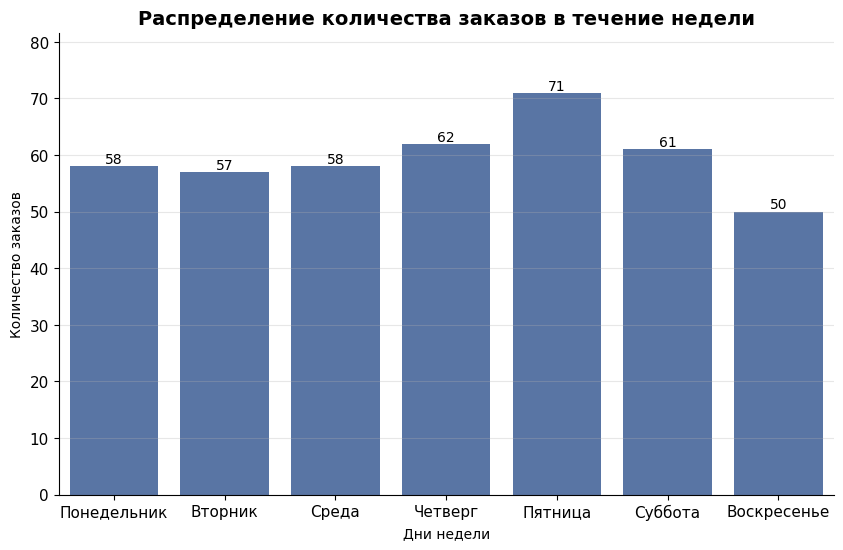

Результаты анализа:
Изменение активности заказов в течение недели:
Понедельник - 58 заказов
Вторник - 57 заказов
Среда - 58 заказов
Четверг - 62 заказов
Пятница - 71 заказов
Суббота - 61 заказов
Воскресенье - 50 заказов


In [162]:
# Создаем фигуру и ось
fig, ax = plt.subplots(figsize=(10, 6))

# Построение диаграммы
sns.barplot(data=orders_by_weekday, ax=ax, color="#4C72B0")

# Настройка осей и названий
plt.xlabel('Дни недели')
plt.ylabel('Количество заказов')
plt.title(
    'Распределение количества заказов в течение недели',
    fontsize = 14,
    weight="bold")

# Добавляем метки над барами
ax.bar_label(ax.containers[0])

# Отображаем сетку по Y
ax.grid(axis='y', alpha=0.3)

# Убираем верхнюю и правую рамку
sns.despine()

# Настраиваем шрифт подписей
ax.tick_params(labelsize=11)

# Настраиваем отступ сверху
ax.set_ylim(0, orders_by_weekday.max() * 1.15)

# Отображение диаграммы
plt.show()

# Выводим результаты
print("Результаты анализа:")
print("====================================================")
print("Изменение активности заказов в течение недели:")
print("\n".join(
    f"{day_of_week} - {orders} заказов"
    for day_of_week, orders in orders_by_weekday.items()
))
print("====================================================")

### Выводы

- Анализ показал наличие недельной сезонности: к концу рабочей недели количество заказов увеличивается, достигая максимума в пятницу, после чего снижается в выходные. Это свидетельствует от том, что спрос зависит от дня недели.

### Интерес для бизнеса

- Знаниние распределения по дням недели помогает планировать количество курьеров и сотрудников, управлять запасами и прогнозировать нагрузку.

- В периоды низкого спроса можно проводить технические работы или запускать маркетинговые акции для увеличения числа заказов.

## **7. Какие виды пиццы приносят наибольшую выручку?**

In [163]:
# Рассчитываем суммарную прибыль по видам пиццы
revenue_by_pizza = (
    df.groupby('name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

result_revenue_pizza = revenue_by_pizza.copy()

result_revenue_pizza.columns = ['Категория', 'Прибыль']

result_revenue_pizza['Доля (%)'] = (
    result_revenue_pizza['Прибыль'] / result_revenue_pizza['Прибыль'].sum() * 100
).round(1)

# Выводим результат
result_revenue_pizza.head(5)

,Категория,Прибыль,Доля (%)
0,The Thai Chicken Pizza,43434.25,5.3
1,The Barbecue Chicken Pizza,42768.00,5.2
2,The California Chicken Pizza,41409.50,5.1
3,The Classic Deluxe Pizza,38180.50,4.7
4,The Spicy Italian Pizza,34831.25,4.3


### Анализ результатов
- Лидерами по выручке являются The Thai Chicken Pizza, The Barbecue Chicken Pizza и The California Chicken Pizza. В совокупности эти три позиции формируют 15,6% общей выручки, несмотря на то что не все из них входят в число самых продаваемых пицц.

### **Гипотеза**

Наиболее продаваемые пиццы не всегда являются наиболее прибыльными.

In [164]:
# Переиспользуем данные по продажам
popular_categories.head()

,name,quantity
0,The Classic Deluxe Pizza,2453
1,The Barbecue Chicken Pizza,2432
2,The Hawaiian Pizza,2422
3,The Pepperoni Pizza,2418
4,The Thai Chicken Pizza,2371


### Анализ результатов

- Несмотря на то что The Classic Deluxe Pizza является самой продаваемой, по объему выручки она занимает лишь четвертое место. Лидером по выручке стала The Thai Chicken Pizza, которая продается немного реже, но имеет более высокую стоимость.

-  Это показывает, что высокий объем продаж не всегда приводит к максимальной выручке. Цена продукта также существенно влияет на финансовый результат.

### **Визуализация**

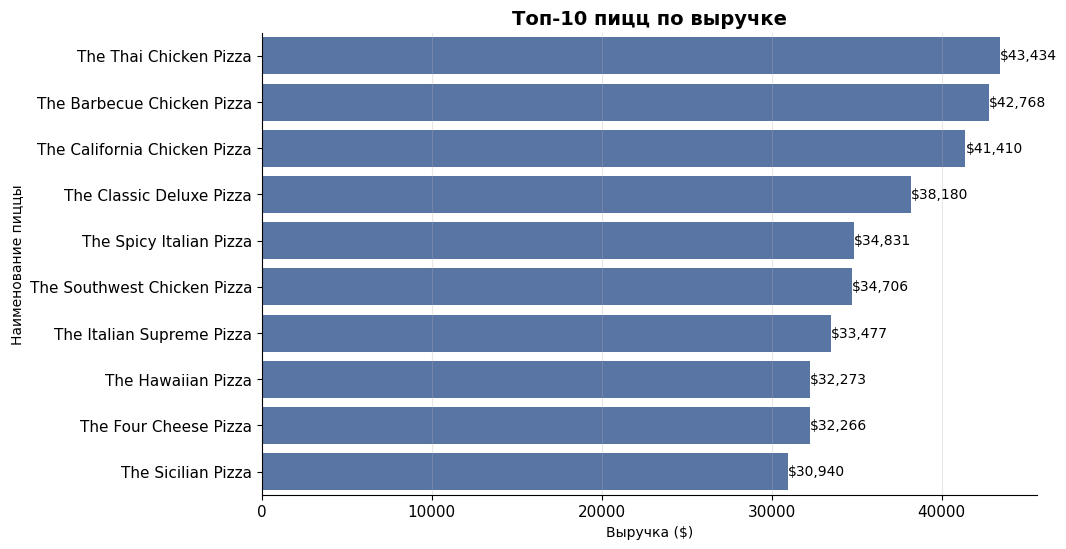

Результаты анализа:
Виды пиццы которые приносят больше всего выручки:
1. The Thai Chicken Pizza — $43,434.25
2. The Barbecue Chicken Pizza — $42,768.00
3. The California Chicken Pizza — $41,409.50
4. The Classic Deluxe Pizza — $38,180.50
5. The Spicy Italian Pizza — $34,831.25
6. The Southwest Chicken Pizza — $34,705.75
7. The Italian Supreme Pizza — $33,476.75
8. The Hawaiian Pizza — $32,273.25
9. The Four Cheese Pizza — $32,265.70
10. The Sicilian Pizza — $30,940.50


In [165]:
# Создание столбчатой диаграммы
fig, ax = plt.subplots(figsize=(10, 6))

# Построение столбчатой диаграммы
sns.barplot(data=revenue_by_pizza.head(10), x='revenue', y='name', ax=ax, color="#4C72B0")


# Настройка осей и названий
ax.set_xlabel('Выручка ($)')
ax.set_ylabel('Наименование пиццы')
ax.set_title(
    'Топ-10 пицц по выручке',
    fontsize = 14,
    weight = 'bold'
)

# Добавляем метки над барами
labels = [f"${v:,.0f}" for v in revenue_by_pizza.head(10)['revenue']]
ax.bar_label(ax.containers[0], labels=labels)

# Отображаем сетку по Y
ax.grid(axis='x', alpha=0.3)

# Убираем верхнюю и правую рамку
sns.despine()

# Настраиваем шрифт подписей
ax.tick_params(labelsize=11)

# Отображение диаграммы
plt.show()

# Выводим результаты
print("Результаты анализа:")
print("====================================================")
print("Виды пиццы которые приносят больше всего выручки:")
print("\n".join(f"{i+1}. {row['name']} — ${row['revenue']:,.2f}" for i, row in revenue_by_pizza.head(10).iterrows()))
print("====================================================")

### Выводы

- Самые популярные пиццы хорошо привлекают покупателей, но не всегда обеспечивают максимальную выручку.

- Более дорогие позиции могут пиносить больше дохода даже при меньшем количестве продаж.

### Интерес для бизнеса

- При разработке маркетинговых компаний стоит учитывать не только объем продаж, но и вклад каждой пиццы в общую выручку.

- Для увеличения дохода можно продвигать ввывсокомаржинальные позиции, если это не приводит к заметному снижению спроса.
